In [1]:
# install dependencies
!pip install transformers datasets torch scikit-learn matplotlib seaborn arxiv -q

In [2]:
# imports
import arxiv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import torch
from transformers import BertTokenizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import re
import warnings
warnings.filterwarnings('ignore')

In [3]:
categories = {
    "cs.AI": "Artificial Intelligence",
    "cs.AR": "Hardware Architecture",
    "cs.CC": "Computational Complexity",
    "cs.CE": "Computational Engineering, Finance, and Science",
    "cs.CG": "Computational Geometry",
    "cs.CL": "Computation and Language",
    "cs.CR": "Cryptography and Security",
    "cs.CV": "Computer Vision and Pattern Recognition",
    "cs.CY": "Computers and Society",
    "cs.DB": "Databases",
    "cs.DC": "Distributed, Parallel, and Cluster Computing",
    "cs.DL": "Digital Libraries",
    "cs.DM": "Discrete Mathematics",
    "cs.DS": "Data Structures and Algorithms",
    "cs.ET": "Emerging Technologies",
    "cs.FL": "Formal Languages and Automata Theory",
    "cs.GL": "General Literature",
    "cs.GR": "Graphics",
    "cs.GT": "Computer Science and Game Theory",
    "cs.HC": "Human-Computer Interaction",
    "cs.IR": "Information Retrieval",
    "cs.IT": "Information Theory",
    "cs.LG": "Machine Learning",
    "cs.LO": "Logic in Computer Science",
    "cs.MA": "Multiagent Systems",
    "cs.MM": "Multimedia",
    "cs.MS": "Mathematical Software",
    "cs.NA": "Numerical Analysis",
    "cs.NE": "Neural and Evolutionary Computing",
    "cs.NI": "Networking and Internet Architecture",
    "cs.OH": "Other Computer Science",
    "cs.OS": "Operating Systems",
    "cs.PF": "Performance",
    "cs.PL": "Programming Languages",
    "cs.RO": "Robotics",
    "cs.SC": "Symbolic Computation",
    "cs.SD": "Sound",
    "cs.SE": "Software Engineering",
    "cs.SI": "Social and Information Networks"
}


In [ ]:
# avoid pagination by staying at 100 papers per category...
# https://lukasschwab.me/arxiv.py/arxiv.html
import time

PAPERS_PER_CATEGORY = 100 # 100 = 1 API page only -> no rate limit issues
# Increase to 500 for final model maybe?

client = arxiv.Client(page_size=100,delay_seconds=10,num_retries=2)

def collect_abstracts(categories, papers_per_cat):
    records = []
    for cat_code, cat_name in categories.items():
        print(f"Fetching {papers_per_cat} papers for: {cat_name} ({cat_code})...")
        success = False
        attempts = 0
        while not success and attempts < 2:
            try:
                search = arxiv.Search(
                    query=f"cat:{cat_code}",
                    max_results=papers_per_cat,
                    sort_by=arxiv.SortCriterion.Relevance # changed this to relevance
                )
                count = 0
                for result in client.results(search):
                    records.append({
                        "category_code": cat_code,
                        "category_name": cat_name,
                        "title": result.title,
                        "abstract": result.summary,
                    })
                    count += 1
                print(f"Got {count} papers.")
                success = True
            except Exception as e:
                attempts += 1
                wait = 10 * attempts  # 30s, then 60s, then 90s
                print(f"Error ({e}). Waiting {wait}s before retry {attempts}/3...")
                time.sleep(wait)
        time.sleep(5)  # 15 second pause between every category

    return pd.DataFrame(records)

df_raw = collect_abstracts(categories, PAPERS_PER_CATEGORY)
print(f"\nTotal papers collected: {len(df_raw)}")
df_raw.head(3)

In [ ]:
# save raw data to CSV
df_raw.to_csv("arxiv_cs_abstracts_raw.csv", index=False)
print("Saved to arxiv_cs_abstracts_raw.csv")

# Later, to reload without re-fetching:
# df_raw = pd.read_csv("arxiv_cs_abstracts_raw.csv")

In [4]:
# Adding helper block to extract pandas df from csv to prevent regeneration problem
df_raw = pd.read_csv('arxiv_cs_abstracts_raw.csv')

In [ ]:
# Exploratory Data Analysis (EDA) !!
# basic stats
print("=== Dataset Overview ===")
print(f"Total samples:{len(df_raw)}")
print(f"Columns:{list(df_raw.columns)}")
print(f"Missing abstracts:{df_raw['abstract'].isnull().sum()}")
print(f"Duplicate entries:{df_raw.duplicated(subset='abstract').sum()}")
print("=== Class Distribution ===")
print(df_raw['category_name'].value_counts())

=== Dataset Overview ===
Total samples:     2600
Columns:           ['category_code', 'category_name', 'title', 'abstract']
Missing abstracts: 0
Duplicate entries: 228

=== Class Distribution ===
category_name
Computational Geometry                     100
Cryptography and Security                  100
Computer Vision and Pattern Recognition    100
Databases                                  100
Digital Libraries                          100
Discrete Mathematics                       100
Emerging Technologies                      100
Formal Languages and Automata Theory       100
General Literature                         100
Computer Science and Game Theory           100
Human-Computer Interaction                 100
Information Retrieval                      100
Information Theory                         100
Machine Learning                           100
Multimedia                                 100
Mathematical Software                      100
Neural and Evolutionary Computing     

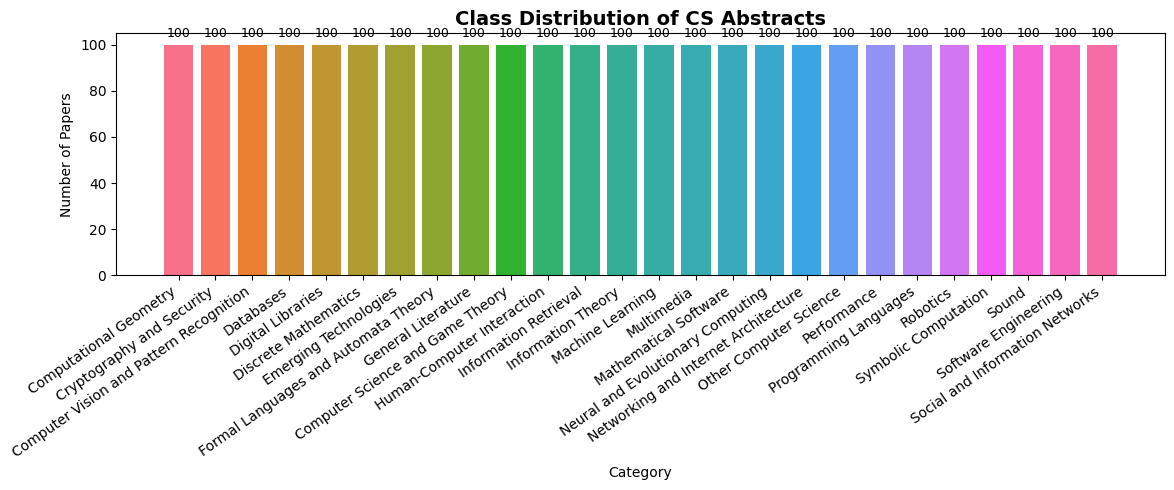

Saved class_distribution.png!


In [6]:
# class distribution bar chart
fig, ax = plt.subplots(figsize=(12, 5))
counts = df_raw['category_name'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=sns.color_palette("husl", len(counts)))
ax.set_title("Class Distribution of CS Abstracts", fontsize=14, fontweight='bold')
ax.set_xlabel("Category")
ax.set_ylabel("Number of Papers")
ax.set_xticklabels(counts.index, rotation=35, ha='right')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("Saved class_distribution.png!")

=== Abstract Length Stats (in words) ===
count    2600.0
mean      160.5
std        57.1
min         3.0
25%       119.0
50%       159.0
75%       200.0
max       385.0
Name: abstract_length, dtype: float64


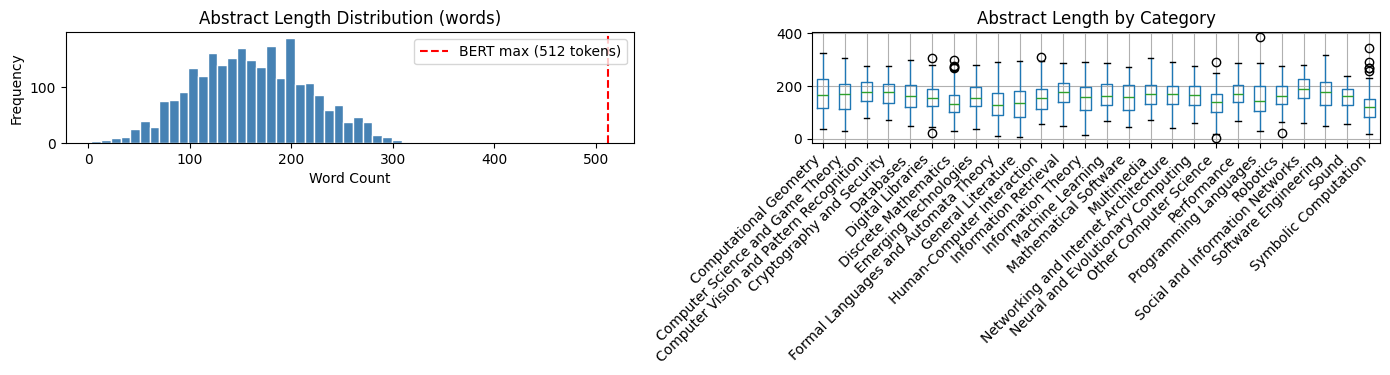

Saved abstract_lengths.png


In [7]:
# abstract length distribution
df_raw['abstract_length'] = df_raw['abstract'].apply(lambda x: len(x.split()))

print("=== Abstract Length Stats (in words) ===")
print(df_raw['abstract_length'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# overall distribution
axes[0].hist(df_raw['abstract_length'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(512, color='red', linestyle='--', label='BERT max (512 tokens)')
axes[0].set_title("Abstract Length Distribution (words)")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# by category (box plot)
df_raw.boxplot(column='abstract_length', by='category_name', ax=axes[1])
axes[1].set_title("Abstract Length by Category")
axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
plt.suptitle("")
plt.tight_layout()
plt.savefig("abstract_lengths.png", dpi=150)
plt.show()
print("Saved abstract_lengths.png")

In [ ]:
# text cleaning
import re
def clean_abstract(text):
    text = re.sub(r'\n', ' ', text) # remove newlines
    text = re.sub(r'\s+', ' ', text)  # collapse whitespace
    text = re.sub(r'[^\x00-\x7F]+', '', text) # remove non-ASCII
    return text.strip()

df = df_raw.copy()
df = df.drop_duplicates(subset='abstract')  # drop duplicates
df = df.dropna(subset=['abstract']) # drop missing
df['abstract_clean'] = df['abstract'].apply(clean_abstract)
print(f"After cleaning: {len(df)} samples (removed {len(df_raw) - len(df)})")

After cleaning: 2372 samples (removed 228)


In [9]:
# encode category labels as integers
le = LabelEncoder()
df['label'] = le.fit_transform(df['category_code'])

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls} ({categories[cls]})")

Label mapping:
  0 → cs.CG (Computational Geometry)
  1 → cs.CR (Cryptography and Security)
  2 → cs.CV (Computer Vision and Pattern Recognition)
  3 → cs.DB (Databases)
  4 → cs.DL (Digital Libraries)
  5 → cs.DM (Discrete Mathematics)
  6 → cs.ET (Emerging Technologies)
  7 → cs.FL (Formal Languages and Automata Theory)
  8 → cs.GL (General Literature)
  9 → cs.GT (Computer Science and Game Theory)
  10 → cs.HC (Human-Computer Interaction)
  11 → cs.IR (Information Retrieval)
  12 → cs.IT (Information Theory)
  13 → cs.LG (Machine Learning)
  14 → cs.MM (Multimedia)
  15 → cs.MS (Mathematical Software)
  16 → cs.NE (Neural and Evolutionary Computing)
  17 → cs.NI (Networking and Internet Architecture)
  18 → cs.OH (Other Computer Science)
  19 → cs.PF (Performance)
  20 → cs.PL (Programming Languages)
  21 → cs.RO (Robotics)
  22 → cs.SC (Symbolic Computation)
  23 → cs.SD (Sound)
  24 → cs.SE (Software Engineering)
  25 → cs.SI (Social and Information Networks)


In [10]:
# 80/10/10 split
train_df, temp_df = train_test_split(df, test_size=0.2,
                                      stratify=df['label'], random_state=1)
val_df, test_df   = train_test_split(temp_df, test_size=0.5,
                                      stratify=temp_df['label'], random_state=1)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


dist_df = pd.DataFrame({
    "Train": train_df['category_name'].value_counts(normalize=True),
    "Val":   val_df['category_name'].value_counts(normalize=True),
    "Test":  test_df['category_name'].value_counts(normalize=True),
}).fillna(0)

print(dist_df)

Train: 1897 | Val: 237 | Test: 238
                                            Train       Val      Test
category_name                                                        
Computational Geometry                   0.042172  0.042194  0.042017
Computer Science and Game Theory         0.040063  0.037975  0.042017
Computer Vision and Pattern Recognition  0.040590  0.037975  0.042017
Cryptography and Security                0.042172  0.042194  0.042017
Databases                                0.041118  0.042194  0.042017
Digital Libraries                        0.041118  0.037975  0.042017
Discrete Mathematics                     0.040063  0.037975  0.042017
Emerging Technologies                    0.041645  0.042194  0.042017
Formal Languages and Automata Theory     0.039536  0.042194  0.037815
General Literature                       0.042172  0.042194  0.042017
Human-Computer Interaction               0.040590  0.037975  0.042017
Information Retrieval                    0.037955  0.03

In [11]:
dist_df.plot(kind='bar', figsize=(10,6))

plt.title("Category Distribution Across Splits")
plt.ylabel("Proportion")
plt.xlabel("Category")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Dataset", loc='lower center', bbox_to_anchor=(0.5, 1.15), ncol=3)
plt.tight_layout()
plt.savefig("category_distribution.png", dpi=300)
plt.close()

In [12]:
# tokenize using BERT's tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# check a sample tokenization
sample = df['abstract_clean'].iloc[0]
tokens = tokenizer(sample, truncation=True, max_length=512)
print(f"Sample abstract (first 100 chars): {sample[:100]}...")
print(f"Number of tokens: {len(tokens['input_ids'])}")
print(f"Token IDs (first 20): {tokens['input_ids'][:20]}")

Sample abstract (first 100 chars): Point cloud analysis is very challenging, as the shape implied in irregular points is difficult to c...
Number of tokens: 212
Token IDs (first 20): [101, 2391, 6112, 4106, 2003, 2200, 10368, 1010, 2004, 1996, 4338, 13339, 1999, 12052, 2685, 2003, 3697, 2000, 5425, 1012]


In [13]:
# tokenize the full dataset
def tokenize_batch(texts, tokenizer, max_length=256):
    return tokenizer(
        list(texts),
        padding='max_length',
        truncation=True,
        max_length=max_length,  # 256 is a good balance of speed vs coverage
        return_tensors='pt'
    )

print("Tokenizing training set...")
train_encodings = tokenize_batch(train_df['abstract_clean'], tokenizer)
print("Tokenizing validation set...")
val_encodings   = tokenize_batch(val_df['abstract_clean'], tokenizer)
print("Tokenizing test set...")
test_encodings  = tokenize_batch(test_df['abstract_clean'], tokenizer)

print("Tokenization complete!")
print(f"Input shape (train): {train_encodings['input_ids'].shape}")

Tokenizing training set...
Tokenizing validation set...
Tokenizing test set...
Tokenization complete!
Input shape (train): torch.Size([1897, 256])


In [17]:
import torch
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built())
print(torch.device("mps" if torch.backends.mps.is_available() else "cpu")) # I don't remember whose not on Mac but if someone has CUDA alter this

True
True
mps


In [19]:
# https://huggingface.co/transformers/v4.2.2/training.html
# BERT training frozen encoder + classification layer
from torch.utils.data import Dataset
from transformers import (BertForSequenceClassification, Trainer,TrainingArguments)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import EarlyStoppingCallback

# https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
class CSAbstractDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: value[idx] for key, value in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = CSAbstractDataset(train_encodings, train_df["label"].tolist())
val_dataset   = CSAbstractDataset(val_encodings, val_df["label"].tolist())
test_dataset  = CSAbstractDataset(test_encodings, test_df["label"].tolist())

model = BertForSequenceClassification.from_pretrained("bert-base-uncased",num_labels=len(le.classes_))
for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir="./bert_frozen_encoder",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    num_train_epochs=20,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-4,  
    weight_decay=0.01,
)

# Citation for compute_metric function: https://huggingface.co/transformers/v4.2.2/training.html
def compute_metrics(pred):
    raw, labels = pred
    preds = np.argmax(raw, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1,"precision": precision, "recall": recall}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,   # use validation here
    compute_metrics=compute_metrics, callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
)

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,3.274619,3.213206,0.092827,0.040115,0.030845,0.089957
2,3.204084,3.172549,0.059072,0.030748,0.031026,0.056410
3,3.162261,3.148257,0.105485,0.046008,0.045073,0.101709
4,3.124241,3.117362,0.135021,0.077072,0.088159,0.129487
5,3.109220,3.095042,0.156118,0.103125,0.146224,0.153953
6,3.080838,3.078765,0.151899,0.092950,0.119146,0.149573
7,3.046931,3.056576,0.194093,0.135977,0.138012,0.191880
8,3.039723,3.042599,0.143460,0.111593,0.161348,0.139316
9,3.021960,3.026160,0.122363,0.091640,0.149049,0.117949
10,3.008651,3.014039,0.189873,0.148024,0.143184,0.184615


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2380, training_loss=3.031133956268054, metrics={'train_runtime': 456.3426, 'train_samples_per_second': 83.139, 'train_steps_per_second': 5.215, 'total_flos': 4992292259082240.0, 'train_loss': 3.031133956268054, 'epoch': 20.0})

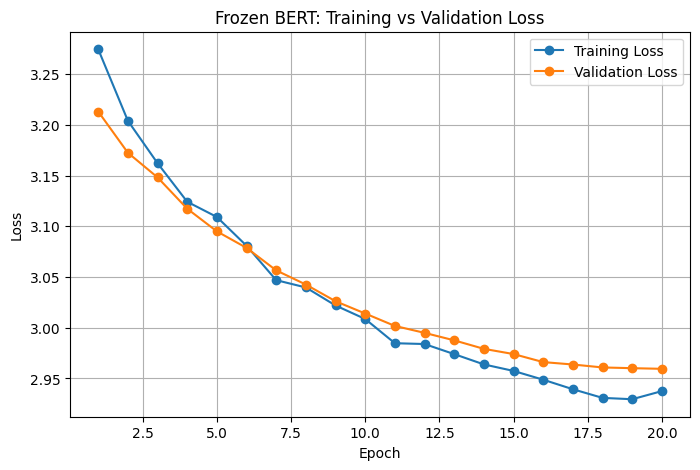

In [20]:
# Figure for validation + training loss, overfitting check!
log_df = pd.DataFrame(trainer.state.log_history)
log_df = log_df[log_df["epoch"].notna()].copy()
train_loss_df = log_df[log_df["loss"].notna()][["epoch", "loss"]].copy()
val_loss_df = log_df[log_df["eval_loss"].notna()][["epoch", "eval_loss"]].copy()
plt.figure(figsize=(8, 5))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Frozen BERT: Training vs Validation Loss")
plt.plot(train_loss_df["epoch"], train_loss_df["loss"], marker="o", label="Training Loss")
plt.plot(val_loss_df["epoch"], val_loss_df["eval_loss"], marker="o", label="Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

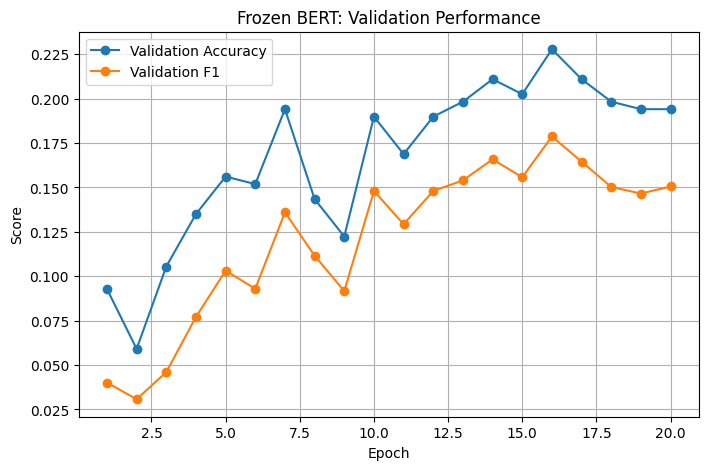

In [21]:
val_metrics_df = log_df[log_df["eval_accuracy"].notna()][["epoch", "eval_accuracy", "eval_f1"]].copy()
plt.figure(figsize=(8, 5))
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Frozen BERT: Validation Performance")
plt.plot(val_metrics_df["epoch"], val_metrics_df["eval_accuracy"], marker="o", label="Validation Accuracy")
plt.plot(val_metrics_df["epoch"], val_metrics_df["eval_f1"], marker="o", label="Validation F1")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# BERT fine tuning (encoder + classification head)
fine_tune_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(le.classes_),
)

fine_tune_training_args = TrainingArguments(
    output_dir="./bert_fine_tuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
)

fine_tune_trainer = Trainer(
    model=fine_tune_model,
    args=fine_tune_training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

fine_tune_trainer.train()

fine_tune_log_df = pd.DataFrame(fine_tune_trainer.state.log_history)
fine_tune_log_df = fine_tune_log_df[fine_tune_log_df["epoch"].notna()].copy()

In [ ]:
fine_tune_train_loss_df = fine_tune_log_df[fine_tune_log_df["loss"].notna()][["epoch", "loss"]].copy()
fine_tune_val_loss_df = fine_tune_log_df[fine_tune_log_df["eval_loss"].notna()][["epoch", "eval_loss"]].copy()

plt.figure(figsize=(8, 5))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuned BERT: Training vs Validation Loss")
plt.plot(fine_tune_train_loss_df["epoch"], fine_tune_train_loss_df["loss"], marker="o", label="Training Loss")
plt.plot(fine_tune_val_loss_df["epoch"], fine_tune_val_loss_df["eval_loss"], marker="o", label="Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

fine_tune_val_metrics_df = fine_tune_log_df[fine_tune_log_df["eval_accuracy"].notna()][["epoch", "eval_accuracy", "eval_f1"]].copy()

plt.figure(figsize=(8, 5))
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Fine-Tuned BERT: Validation Performance")
plt.plot(fine_tune_val_metrics_df["epoch"], fine_tune_val_metrics_df["eval_accuracy"], marker="o", label="Validation Accuracy")
plt.plot(fine_tune_val_metrics_df["epoch"], fine_tune_val_metrics_df["eval_f1"], marker="o", label="Validation F1")
plt.legend()
plt.grid(True)
plt.show()